# EEG/EOG dataset overview

## tl;dr

- The complete corpus contains **1,800 canonical blocks and 3,600 FIF files** across 33 subject IDs:
  1,260 `exec` blocks and 540 `patt` blocks.
- All FIF pairs use 1,000 Hz, one stable 63-channel EEG order, and one stable 5-channel EOG order.
  EEG metadata records a 1–40 Hz passband and complete digitization information.
- All 540 `patt` blocks last 26 s. Among `exec`, 1,200 blocks last 16 s, 59 last 15.499 s, and one
  lasts 15.414 s; downstream transforms must derive time axes from each block rather than assume 16 s.
- In the deterministic 16-block signal sample, EEG values were finite. `exec` EOG had no missing
  samples, while `patt` `EOG_x`/`EOG_y` averaged 18.3% missingness and included one fully missing block.
- PSD and relative band-power topographies are descriptive sample checks. They are not evidence of a
  class effect or a validated preprocessing/normalization policy.

## Context & Methods

This notebook audits the raw FIF/JSON corpus before spectral preprocessing is implemented.

- Corpus counts and FIF metadata are checked for **all 1,800 canonical blocks**.
- Signal-dependent PSD, EOG quality metrics, and topographies use a deterministic stratified sample of
  16 blocks (8 `exec`, 8 `patt`; balanced by `geometric`/`random` where available).
- `Data_Train`/`exec` and `Data_Pattern`/`patt` are recording families, not an inferred ML split.
- Subject, trial, and block identity remain explicit throughout the analysis.

### Key Assumptions

- FIF files and `labels.json` are the source of truth.
- Recorded EEG units have not been independently validated, so amplitudes are reported in stored units,
  not labelled as microvolts.
- Relative band power supports spatial comparison within this overview. It is not a normalization policy
  for future ML experiments.
- Signal-level findings from the 16-block sample are descriptive, not population estimates.

### 1. Setup

In [1]:
import os
import sys
from collections import Counter
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-overview")

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import welch


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.datasets import DatasetBase, NumpyDataset


FAMILIES = {
    "exec": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Train",
        "step_type": "exec",
    },
    "patt": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Pattern",
        "step_type": "patt",
    },
}
SIGNAL_SAMPLES_PER_FAMILY = 8
BANDS_HZ = {
    "delta (2-4 Hz)": (2.0, 4.0),
    "theta (4-8 Hz)": (4.0, 8.0),
    "alpha (8-13 Hz)": (8.0, 13.0),
    "beta (13-30 Hz)": (13.0, 30.0),
    "low gamma (30-40 Hz)": (30.0, 40.0),
}

pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "mne_version": mne.__version__,
        "numpy_version": np.__version__,
        "signal_samples_per_family": SIGNAL_SAMPLES_PER_FAMILY,
    }
)

project_root                 /home/slauva/Projects/master-thesis-2024-2026/...
mne_version                                                             1.11.0
numpy_version                                                            2.4.4
signal_samples_per_family                                                    8
dtype: object

## Data

### 2. Index the complete corpus

The canonical observation is one block identified by `(subject_id, trial_number, block_index)`.
Indexing reads labels and validates paired FIF paths without loading signal arrays.

,subjects,trials,blocks,fif_files,geometric,random
family,,,,,,
exec,33,60,1260,2520,840,420
patt,33,60,540,1080,360,180


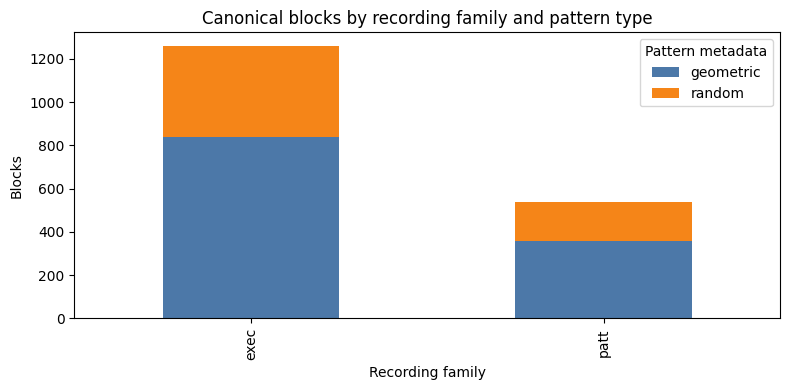

In [2]:
datasets = {
    family: DatasetBase(
        settings["dataset_dir"],
        dataset_step_type=settings["step_type"],
    )
    for family, settings in FAMILIES.items()
}

corpus_rows = []
for family, dataset in datasets.items():
    type_counts = Counter(sample.type for sample in dataset)
    trial_keys = {(sample.subject_id, sample.trial_number) for sample in dataset}
    corpus_rows.append(
        {
            "family": family,
            "subjects": len(dataset.source_map),
            "trials": len(trial_keys),
            "blocks": len(dataset),
            "fif_files": 2 * len(dataset),
            "geometric": type_counts["geometric"],
            "random": type_counts["random"],
        }
    )

corpus_summary = pd.DataFrame(corpus_rows).set_index("family")
display(corpus_summary)

type_plot = corpus_summary[["geometric", "random"]].plot.bar(
    stacked=True,
    figsize=(8, 4),
    color=["#4C78A8", "#F58518"],
)
type_plot.set(
    title="Canonical blocks by recording family and pattern type",
    xlabel="Recording family",
    ylabel="Blocks",
)
type_plot.legend(title="Pattern metadata")
plt.tight_layout()
plt.show()

### 3. Audit every FIF header

This pass opens all EEG and EOG files with `preload=False`. It checks sampling frequency, duration,
channel count/order, stored filter metadata, and whether EEG digitization points are present.

files sfreq_values         duration_values  \
family modality                                               
exec   eeg        1260     [1000.0]  [15.414, 15.499, 16.0]   
       eog        1260     [1000.0]  [15.414, 15.499, 16.0]   
patt   eeg         540     [1000.0]                  [26.0]   
       eog         540     [1000.0]                  [26.0]   

                channel_count_values  channel_orders highpass_values  \
family modality                                                        
exec   eeg                      [63]               1           [1.0]   
       eog                       [5]               1           [0.0]   
patt   eeg                      [63]               1           [1.0]   
       eog                       [5]               1           [0.0]   

                lowpass_values  digitization_rate  
family modality                                    
exec   eeg              [40.0]                1.0  
       eog             [500.0]                0.0  
patt   eeg              [40.0]                1.0  
       eog             [500.0]                0.0

blocks
family duration_seconds        
exec   15.414                 1
       15.499                59
       16.000              1200
patt   26.000               540

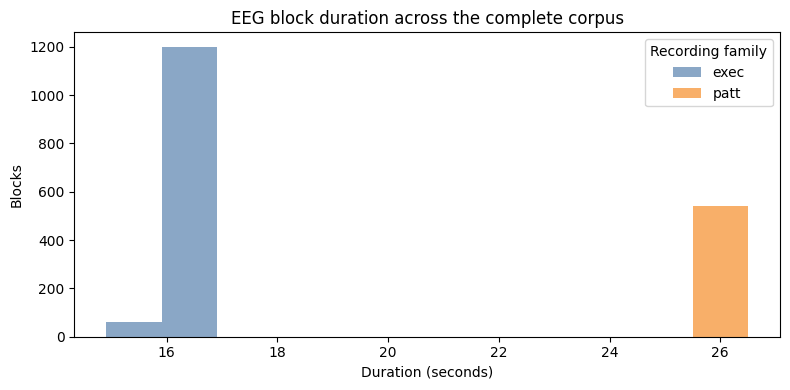

In [3]:
metadata_rows = []
for family, dataset in datasets.items():
    for sample in dataset:
        for modality, path in (("eeg", sample.eeg_path), ("eog", sample.eog_path)):
            raw = mne.io.read_raw_fif(path, preload=False, verbose="ERROR")
            try:
                metadata_rows.append(
                    {
                        "family": family,
                        "subject_id": sample.subject_id,
                        "trial_number": sample.trial_number,
                        "block_index": sample.block_index,
                        "modality": modality,
                        "sfreq_hz": float(raw.info["sfreq"]),
                        "n_times": int(raw.n_times),
                        "duration_seconds": float((raw.n_times - 1) / raw.info["sfreq"]),
                        "n_channels": len(raw.ch_names),
                        "channel_signature": "|".join(raw.ch_names),
                        "highpass_hz": float(raw.info["highpass"]),
                        "lowpass_hz": float(raw.info["lowpass"]),
                        "has_digitization": bool(raw.info["dig"]),
                    }
                )
            finally:
                raw.close()

metadata = pd.DataFrame(metadata_rows)
metadata_summary = (
    metadata.groupby(["family", "modality"], observed=True)
    .agg(
        files=("n_times", "size"),
        sfreq_values=("sfreq_hz", lambda values: sorted(set(values))),
        duration_values=("duration_seconds", lambda values: sorted(set(values))),
        channel_count_values=("n_channels", lambda values: sorted(set(values))),
        channel_orders=("channel_signature", "nunique"),
        highpass_values=("highpass_hz", lambda values: sorted(set(values))),
        lowpass_values=("lowpass_hz", lambda values: sorted(set(values))),
        digitization_rate=("has_digitization", "mean"),
    )
)
display(metadata_summary)
display(
    metadata.loc[metadata["modality"] == "eeg"]
    .groupby(["family", "duration_seconds"], observed=True)
    .size()
    .rename("blocks")
    .to_frame()
)

fig, axis = plt.subplots(figsize=(8, 4))
for family, color in (("exec", "#4C78A8"), ("patt", "#F58518")):
    values = metadata.loc[
        (metadata["family"] == family) & (metadata["modality"] == "eeg"),
        "duration_seconds",
    ]
    axis.hist(values, bins=np.arange(values.min() - 0.5, values.max() + 1.5, 1.0), alpha=0.65, label=family, color=color)
axis.set(
    title="EEG block duration across the complete corpus",
    xlabel="Duration (seconds)",
    ylabel="Blocks",
)
axis.legend(title="Recording family")
plt.tight_layout()
plt.show()

### 4. Select a deterministic signal sample

Eight evenly spaced, distinct subjects are selected per family. Pattern types alternate to include four
geometric and four random blocks. The first matching block in stable dataset order is used.

In [4]:
def select_signal_samples(dataset: DatasetBase, count: int):
    subject_ids = sorted(dataset.source_map)
    subject_positions = np.linspace(0, len(subject_ids) - 1, count, dtype=int)
    selected = []
    for position_index, subject_position in enumerate(subject_positions):
        subject_id = subject_ids[subject_position]
        pattern_type = "geometric" if position_index % 2 == 0 else "random"
        matching = [
            sample
            for sample in dataset
            if sample.subject_id == subject_id and sample.type == pattern_type
        ]
        if not matching:
            raise ValueError(
                f"No {pattern_type} sample available for subject={subject_id}"
            )
        selected.append(matching[0])
    return selected


selected_rows = []
selected_keys = {}
for family, dataset in datasets.items():
    selected = select_signal_samples(dataset, SIGNAL_SAMPLES_PER_FAMILY)
    selected_keys[family] = [
        (sample.subject_id, sample.trial_number, sample.block_index) for sample in selected
    ]
    selected_rows.extend(
        {
            "family": family,
            "subject_id": sample.subject_id,
            "trial_number": sample.trial_number,
            "block_index": sample.block_index,
            "pattern_type": sample.type,
        }
        for sample in selected
    )

signal_sample_index = pd.DataFrame(selected_rows)
display(signal_sample_index)

,family,subject_id,trial_number,block_index,pattern_type
0,exec,1,1,1,geometric
1,exec,5,1,15,random
2,exec,10,1,1,geometric
3,exec,14,1,15,random
4,exec,19,1,1,geometric
5,exec,24,1,15,random
6,exec,29,1,1,geometric
7,exec,34,1,15,random
8,patt,1,1,1,geometric
9,patt,5,1,7,random


## Results

### 5. Measure EOG missingness and event rates

`EOG_x`, `EOG_y`, and `EOG_pupil` are treated as continuous auxiliary channels.
`EOG_blink` and `EOG_saccade` are treated as binary event indicators. No interpolation or imputation
is performed.

sampled_blocks  mean_missing_fraction  \
family channel                                              
exec   EOG_blink                 8               0.000000   
       EOG_pupil                 8               0.000000   
       EOG_saccade               8               0.000000   
       EOG_x                     8               0.000000   
       EOG_y                     8               0.000000   
patt   EOG_blink                 8               0.000000   
       EOG_pupil                 8               0.000000   
       EOG_saccade               8               0.000000   
       EOG_x                     8               0.183041   
       EOG_y                     8               0.183041   

                    max_missing_fraction  mean_event_fraction  
family channel                                                 
exec   EOG_blink                     0.0             0.171927  
       EOG_pupil                     0.0                  NaN  
       EOG_saccade                   0.0             0.210932  
       EOG_x                         0.0                  NaN  
       EOG_y                         0.0                  NaN  
patt   EOG_blink                     0.0             0.182974  
       EOG_pupil                     0.0                  NaN  
       EOG_saccade                   0.0             0.250312  
       EOG_x                         1.0                  NaN  
       EOG_y                         1.0                  NaN

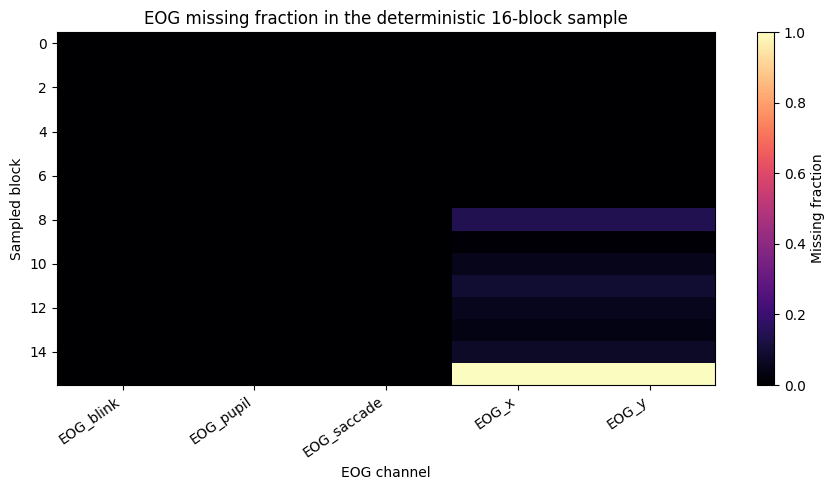

mean    median       min  max
family channel                                       
exec   EOG_blink    0.171927  0.034717  0.010062  1.0
       EOG_saccade  0.210932  0.077651  0.038373  1.0
patt   EOG_blink    0.182974  0.067209  0.010077  1.0
       EOG_saccade  0.250312  0.148437  0.076459  1.0

In [5]:
numpy_datasets = {
    family: NumpyDataset(
        settings["dataset_dir"],
        dataset_step_type=settings["step_type"],
        cache_policy=None,
    )
    for family, settings in FAMILIES.items()
}

eog_rows = []
loaded_signal_samples = {}
for family, keys in selected_keys.items():
    loaded_signal_samples[family] = []
    for key in keys:
        loaded = numpy_datasets[family][key]
        loaded_signal_samples[family].append(loaded)
        for channel_name, values in zip(loaded.eog_channels, loaded.eog, strict=True):
            finite = np.isfinite(values)
            is_event = channel_name in {"EOG_blink", "EOG_saccade"}
            eog_rows.append(
                {
                    "family": family,
                    "subject_id": key[0],
                    "trial_number": key[1],
                    "block_index": key[2],
                    "channel": channel_name,
                    "missing_fraction": float(1.0 - finite.mean()),
                    "event_fraction": float(np.nanmean(values)) if is_event else np.nan,
                }
            )

eog_quality = pd.DataFrame(eog_rows)
eog_summary = (
    eog_quality.groupby(["family", "channel"], observed=True)
    .agg(
        sampled_blocks=("block_index", "size"),
        mean_missing_fraction=("missing_fraction", "mean"),
        max_missing_fraction=("missing_fraction", "max"),
        mean_event_fraction=("event_fraction", "mean"),
    )
)
display(eog_summary)

missing_pivot = eog_quality.pivot_table(
    index=["family", "subject_id", "trial_number", "block_index"],
    columns="channel",
    values="missing_fraction",
)
fig, axis = plt.subplots(figsize=(9, 5))
image = axis.imshow(missing_pivot.to_numpy(), aspect="auto", vmin=0.0, vmax=1.0, cmap="magma")
axis.set(
    title="EOG missing fraction in the deterministic 16-block sample",
    xlabel="EOG channel",
    ylabel="Sampled block",
)
axis.set_xticks(range(len(missing_pivot.columns)), missing_pivot.columns, rotation=35, ha="right")
fig.colorbar(image, ax=axis, label="Missing fraction")
plt.tight_layout()
plt.show()

event_summary = (
    eog_quality.dropna(subset=["event_fraction"])
    .groupby(["family", "channel"], observed=True)["event_fraction"]
    .agg(["mean", "median", "min", "max"])
)
display(event_summary)

### 6. Estimate PSD and relative band power

Welch PSD uses 4-second periodic Hann windows with 50% overlap. Absolute PSD remains in squared stored
units per Hz. Topographies use each channel's band power divided by its total 2–40 Hz power.

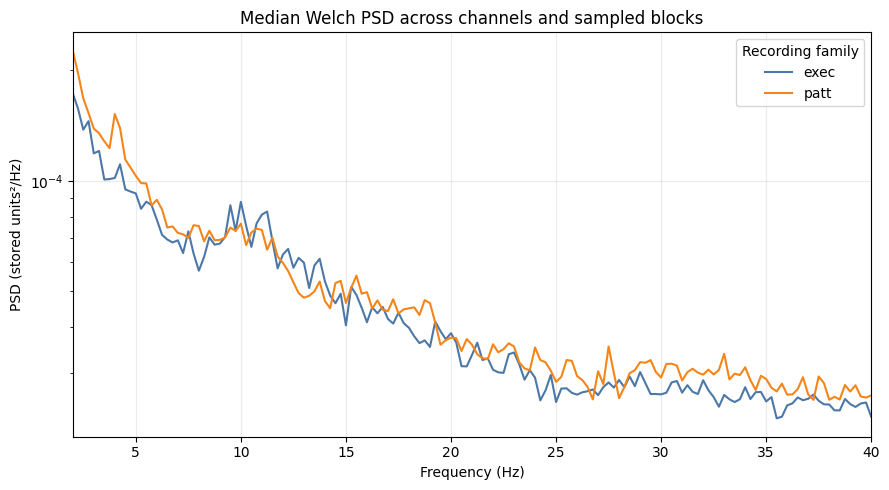

In [6]:
psd_records = []
relative_band_power = {family: [] for family in FAMILIES}
topomap_info = {}

for family, loaded_samples in loaded_signal_samples.items():
    for loaded in loaded_samples:
        if not np.isfinite(loaded.eeg).all():
            raise ValueError(f"Non-finite EEG values in {family} sample {loaded.sample}")

        nperseg = min(int(4 * loaded.sfreq), loaded.eeg.shape[-1])
        frequencies, psd = welch(
            loaded.eeg,
            fs=loaded.sfreq,
            window="hann",
            nperseg=nperseg,
            noverlap=nperseg // 2,
            detrend="constant",
            scaling="density",
            axis=-1,
        )
        analysis_mask = (frequencies >= 2.0) & (frequencies <= 40.0)
        total_power = np.trapezoid(psd[:, analysis_mask], frequencies[analysis_mask], axis=-1)

        block_band_power = []
        for band_name, (low_hz, high_hz) in BANDS_HZ.items():
            include_high = high_hz == 40.0
            band_mask = (frequencies >= low_hz) & (
                frequencies <= high_hz if include_high else frequencies < high_hz
            )
            band_power = np.trapezoid(psd[:, band_mask], frequencies[band_mask], axis=-1)
            relative_power = np.zeros_like(band_power)
            np.divide(band_power, total_power, out=relative_power, where=total_power > 0)
            block_band_power.append(relative_power)

        relative_band_power[family].append(np.stack(block_band_power))
        psd_records.append(
            {
                "family": family,
                "frequencies": frequencies[analysis_mask],
                "median_channel_psd": np.median(psd[:, analysis_mask], axis=0),
            }
        )

        if family not in topomap_info:
            raw = mne.io.read_raw_fif(loaded.sample.eeg_path, preload=False, verbose="ERROR")
            try:
                topomap_info[family] = raw.info.copy()
            finally:
                raw.close()

for family in relative_band_power:
    relative_band_power[family] = np.stack(relative_band_power[family])

fig, axis = plt.subplots(figsize=(9, 5))
for family, color in (("exec", "#4C78A8"), ("patt", "#F58518")):
    family_psds = [
        record["median_channel_psd"] for record in psd_records if record["family"] == family
    ]
    frequencies = next(
        record["frequencies"] for record in psd_records if record["family"] == family
    )
    median_psd = np.median(np.stack(family_psds), axis=0)
    axis.semilogy(frequencies, median_psd, label=family, color=color)
axis.set(
    title="Median Welch PSD across channels and sampled blocks",
    xlabel="Frequency (Hz)",
    ylabel="PSD (stored units²/Hz)",
    xlim=(2, 40),
)
axis.grid(alpha=0.25)
axis.legend(title="Recording family")
plt.tight_layout()
plt.show()

### 7. Plot relative band-power topographies

Each map is the median relative power across sampled blocks. Shared colour limits within each frequency
band allow comparison between `exec` and `patt`, but no inferential claim is made.

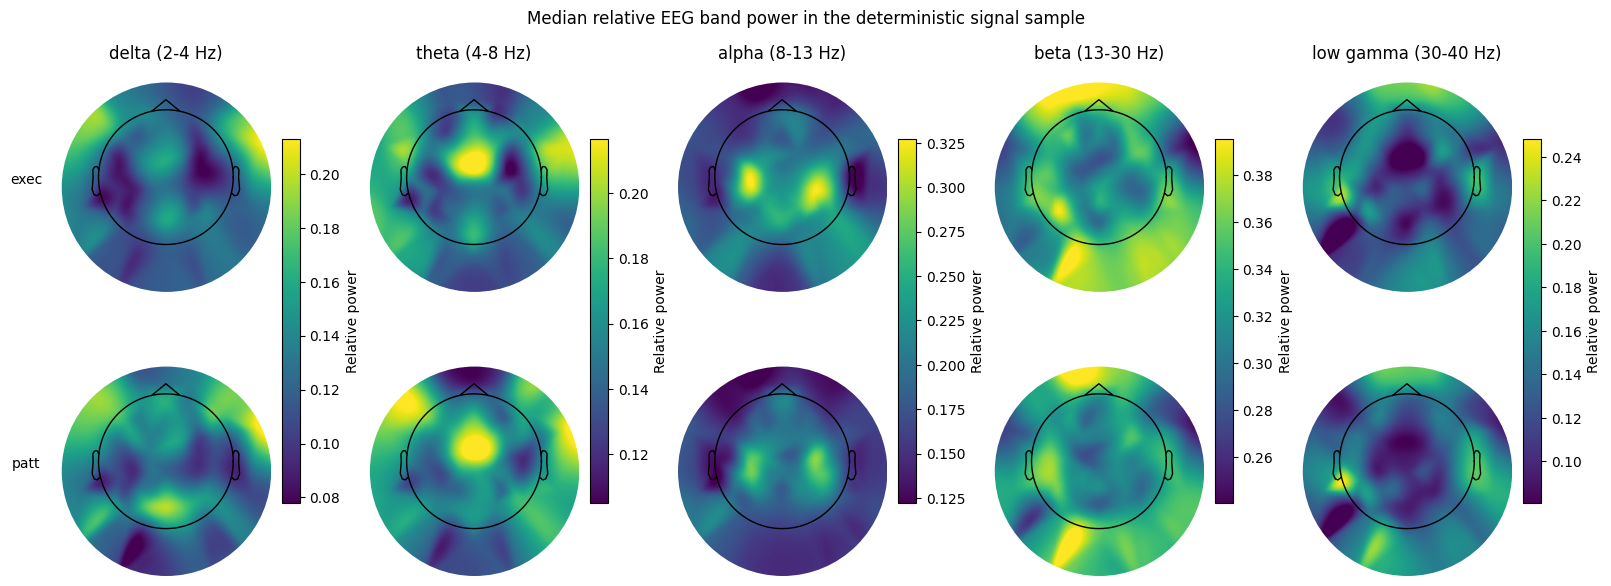

In [7]:
band_names = list(BANDS_HZ)
family_order = ["exec", "patt"]
topomap_values = {
    family: np.median(relative_band_power[family], axis=0) for family in family_order
}

fig, axes = plt.subplots(
    len(family_order),
    len(band_names),
    figsize=(16, 6),
    constrained_layout=True,
)
for band_index, band_name in enumerate(band_names):
    combined = np.concatenate(
        [topomap_values[family][band_index] for family in family_order]
    )
    vmin, vmax = float(combined.min()), float(combined.max())
    images = []
    for family_index, family in enumerate(family_order):
        axis = axes[family_index, band_index]
        image, _ = mne.viz.plot_topomap(
            topomap_values[family][band_index],
            topomap_info[family],
            axes=axis,
            show=False,
            contours=0,
            sensors=False,
            cmap="viridis",
            vlim=(vmin, vmax),
            sphere="eeg",
        )
        images.append(image)
        axis.set_title(band_name if family_index == 0 else "")
        if band_index == 0:
            axis.set_ylabel(family, rotation=0, labelpad=25, va="center")
    fig.colorbar(images[-1], ax=axes[:, band_index], shrink=0.65, label="Relative power")

fig.suptitle("Median relative EEG band power in the deterministic signal sample")
plt.show()

## Checks

The checks below distinguish full-corpus invariants from sample-level calculations.

In [8]:
assert corpus_summary.loc["exec", "blocks"] == 1260
assert corpus_summary.loc["patt", "blocks"] == 540
assert len(metadata) == 2 * int(corpus_summary["blocks"].sum())

paired = metadata.pivot(
    index=["family", "subject_id", "trial_number", "block_index"],
    columns="modality",
    values=["sfreq_hz", "n_times"],
)
assert np.allclose(paired["sfreq_hz"]["eeg"], paired["sfreq_hz"]["eog"])
assert np.array_equal(paired["n_times"]["eeg"], paired["n_times"]["eog"])
assert set(metadata["sfreq_hz"]) == {1000.0}
assert set(metadata.loc[metadata["modality"] == "eeg", "n_channels"]) == {63}
assert set(metadata.loc[metadata["modality"] == "eog", "n_channels"]) == {5}
assert len(signal_sample_index) == 2 * SIGNAL_SAMPLES_PER_FAMILY
assert signal_sample_index.groupby("family")["subject_id"].nunique().eq(SIGNAL_SAMPLES_PER_FAMILY).all()
assert signal_sample_index.groupby(["family", "pattern_type"]).size().eq(SIGNAL_SAMPLES_PER_FAMILY // 2).all()
assert all(np.isfinite(values).all() for values in topomap_values.values())

pd.Series(
    {
        "complete_blocks_checked": len(paired),
        "fif_headers_checked": len(metadata),
        "signal_blocks_checked": len(signal_sample_index),
        "all_eeg_finite_in_signal_sample": True,
        "all_checks_passed": True,
    }
)

complete_blocks_checked            1800
fif_headers_checked                3600
signal_blocks_checked                16
all_eeg_finite_in_signal_sample    True
all_checks_passed                  True
dtype: object

## Takeaways

1. A common spectral API can rely on 1,000 Hz input, 63 EEG channels, stable channel order, and an
   available EEG montage across the current corpus.
2. Block duration is not perfectly uniform in `exec`; output times and cache manifests must preserve
   the actual `n_times`/duration for every canonical sample.
3. EOG cannot share a blind EEG transform path. Continuous gaze channels may contain substantial NaN
   regions, while blink and saccade channels are binary indicators with strongly varying occupancy.
4. The stored EEG passband supports the planned 2–40 Hz analysis. Reapplying an assumed notch or
   extending analysis above 40 Hz would not be justified by the current source metadata.
5. The overview does not define a prediction target or an ML split. `exec` and `patt` remain recording
   families and potential condition boundaries.